# FaceRankNet — Master Colab Notebook
**Feature-Decomposed Facial Beauty Prediction**  
Dataset: SCUT-FBP5500 | Framework: PyTorch + DGL + MediaPipe

---
**Drive folder structure:**
```
MyDrive/Colab Notebooks/FaceRankNet/FaceRankNet/
  ├── config.py, preprocessing.py, dataset.py, model.py ...
  ├── run_colab.ipynb
  └── cache/   <- auto-created, persists across sessions
```
Run cells **in order**.

In [3]:
import sys, os

# Install DGL without touching torch or numpy (--no-deps)
!pip install dgl --no-deps -f https://data.dgl.ai/wheels/cu121/repo.html -q

# MediaPipe & CV
!pip install -q "mediapipe>=0.10" opencv-python-headless

# Scientific stack
!pip install -q pandas scikit-learn tqdm matplotlib scipy

# DGL dependency
!pip install -q torchdata

# Kaggle dataset downloader
!pip install -q kagglehub

print("Done. Continue to Cell 2.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.5/467.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.9 MB/s eta 0:00:00
Done. Continue to Cell 2.


In [4]:

import sys, types

if 'dgl.graphbolt' not in sys.modules:
    _gb = types.ModuleType('dgl.graphbolt')
    _gb.load_graphbolt = lambda: None
    sys.modules['dgl.graphbolt'] = _gb
    print('✓ DGL graphbolt pre-patched')

import dgl, torch
print(f'DGL     : {dgl.__version__}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

# Sanity check: confirm DGL can move a graph to GPU
if torch.cuda.is_available():
    _g = dgl.graph(([0], [1]))
    _g = _g.to('cuda')
    print('✓ DGL CUDA graph test passed')
else:
    print('⚠ No GPU detected — re-check Runtime -> Change runtime type -> T4 GPU')

✓ DGL graphbolt pre-patched
Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


DGL backend not selected or invalid.  Assuming PyTorch for now.


DGL     : 2.1.0+cu121
PyTorch : 2.11.0+cu128
CUDA    : True
✓ DGL CUDA graph test passed


In [7]:
# ============================================================
# Cell 3 — Mount Drive, copy project files, (opsional) download dataset
#
# Kaggle download di-skip jika:
#   - TRAIN_CSV + TEST_CSV sudah ada di Drive  (gak perlu labels.txt), DAN
#   - Landmark caches sudah ada di Drive       (gak perlu images)
# CSV split di-skip jika TRAIN_CSV + TEST_CSV sudah ada.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, pandas as pd
from sklearn.model_selection import train_test_split

DRIVE_ROOT   = '/content/drive/MyDrive/Colab Notebooks/FaceRankNet/FaceRankNet8'
PROJECT_ROOT = '/content/FaceRankNet'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(CACHE_DIR,    exist_ok=True)

# ── Copy .py files from Drive to runtime ────────────────────────────────────
copied = []
for fname in os.listdir(DRIVE_ROOT):
    if fname.endswith('.py'):
        shutil.copy(os.path.join(DRIVE_ROOT, fname), os.path.join(PROJECT_ROOT, fname))
        copied.append(fname)
sys.path.insert(0, PROJECT_ROOT)
print(f'Copied {len(copied)} .py files: {copied}')

# ── Define all paths ────────────────────────────────────────────────────────
TRAIN_CSV     = f'{DRIVE_ROOT}/train_labels.csv'
TEST_CSV      = f'{DRIVE_ROOT}/test_labels.csv'
CACHE_TRAIN   = f'{CACHE_DIR}/train_landmarks.pkl'
CACHE_TEST    = f'{CACHE_DIR}/test_landmarks.pkl'
AVG_FACE_PATH = f'{CACHE_DIR}/avg_face.npy'
PSEUDO_PATH   = f'{CACHE_DIR}/pseudo_labels.pkl'
CHECKPOINT    = f'{DRIVE_ROOT}/checkpoint_best.pt'

# ── Cache status check ───────────────────────────────────────────────────────
csvs_exist       = os.path.exists(TRAIN_CSV)   and os.path.exists(TEST_CSV)
landmarks_cached = os.path.exists(CACHE_TRAIN) and os.path.exists(CACHE_TEST)

print(f'\nCache status:')
print(f'  train_labels.csv    : {"✓" if os.path.exists(TRAIN_CSV) else "✗"}')
print(f'  test_labels.csv     : {"✓" if os.path.exists(TEST_CSV) else "✗"}')
print(f'  train_landmarks.pkl : {"✓" if os.path.exists(CACHE_TRAIN) else "✗"}')
print(f'  test_landmarks.pkl  : {"✓" if os.path.exists(CACHE_TEST) else "✗"}')
print(f'  avg_face.npy        : {"✓" if os.path.exists(AVG_FACE_PATH) else "✗"}')
print(f'  pseudo_labels.pkl   : {"✓" if os.path.exists(PSEUDO_PATH) else "✗"}')
print(f'  checkpoint_best.pt  : {"✓" if os.path.exists(CHECKPOINT) else "✗"}')

# ── Kaggle download (skip jika CSVs + landmark caches sudah ada) ─────────────
if csvs_exist and landmarks_cached:
    print('\n✓ CSVs dan landmark caches sudah ada — skip Kaggle download')
    IMAGE_DIR = None  # tidak dibutuhkan; Cell 4 juga akan skip extraction
else:
    import kagglehub
    print('\nDownloading SCUT-FBP5500 dari Kaggle ...')
    KAGGLE_PATH = kagglehub.dataset_download(
        'pranavchandane/scut-fbp5500-v2-facial-beauty-scores')
    print('Downloaded to:', KAGGLE_PATH)

    IMAGE_DIR   = os.path.join(KAGGLE_PATH, 'Images', 'Images')
    LABELS_FILE = os.path.join(KAGGLE_PATH, 'labels.txt')

    if not os.path.isdir(IMAGE_DIR):
        for root, _, files in os.walk(KAGGLE_PATH):
            if any(f.lower().endswith(('.jpg', '.png')) for f in files):
                IMAGE_DIR = root; break
    if not os.path.isfile(LABELS_FILE):
        for root, _, files in os.walk(KAGGLE_PATH):
            if 'labels.txt' in files:
                LABELS_FILE = os.path.join(root, 'labels.txt'); break

    n_img = len([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg', '.png'))])
    print(f'Image dir: {IMAGE_DIR}  ({n_img} images)')

# ── Parse labels + train/test split (skip jika CSVs sudah ada) ───────────────
if not csvs_exist:
    df = pd.read_csv(LABELS_FILE, sep=' ', header=None, names=['Filename', 'Rating'])
    df['Ethnicity'] = df['Filename'].apply(
        lambda f: 'Asian' if f[0].upper() == 'A' else 'Caucasian')
    df['Gender'] = df['Filename'].apply(
        lambda f: 'Female' if f[1].upper() == 'F' else 'Male')
    print('Ethnicity dist:', df['Ethnicity'].value_counts().to_dict())
    print('Gender dist:',    df['Gender'].value_counts().to_dict())

    df['_b'] = df['Rating'].round(0).astype(int).clip(1, 5)
    train_df, test_df = train_test_split(
        df.drop(columns=['_b']), test_size=0.20, random_state=42, stratify=df['_b'])
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    train_df.to_csv(TRAIN_CSV, index=False)
    test_df.to_csv(TEST_CSV,   index=False)
    print(f'Train: {len(train_df)} | Test: {len(test_df)} — saved to Drive')
else:
    train_df = pd.read_csv(TRAIN_CSV)
    test_df  = pd.read_csv(TEST_CSV)
    # Backfill Ethnicity/Gender jika CSV di-save sebelum kolom ini ada
    _needs_resave = False
    for _df in [train_df, test_df]:
        if 'Ethnicity' not in _df.columns:
            _df['Ethnicity'] = _df['Filename'].apply(
                lambda f: 'Asian' if f[0].upper() == 'A' else 'Caucasian')
            _needs_resave = True
        if 'Gender' not in _df.columns:
            _df['Gender'] = _df['Filename'].apply(
                lambda f: 'Female' if f[1].upper() == 'F' else 'Male')
            _needs_resave = True
    if _needs_resave:
        train_df.to_csv(TRAIN_CSV, index=False)
        test_df.to_csv(TEST_CSV,   index=False)
        print('  ↳ Backfilled Ethnicity/Gender columns & re-saved CSVs to Drive')
    print(f'\n✓ CSVs loaded dari Drive: Train={len(train_df)} | Test={len(test_df)}')

print(f'\nAll paths ready. CHECKPOINT: {CHECKPOINT}')


ValueError: mount failed

In [4]:
# ============================================================
# Cell 4 — Extract & cache landmarks  (~20-40 min, saved to Drive)
# Skips extraction jika cache .pkl sudah ada di Drive.
# ============================================================
import os, pickle
from preprocessing import preprocess_dataset

if os.path.exists(CACHE_TRAIN):
    print(f'✓ Cache ditemukan: {CACHE_TRAIN} — load saja (skip extraction)')
    with open(CACHE_TRAIN, 'rb') as f:
        train_coords = pickle.load(f)
else:
    print('Processing TRAIN set ...')
    train_coords = preprocess_dataset(
        image_dir=IMAGE_DIR, csv_path=TRAIN_CSV, cache_path=CACHE_TRAIN)

if os.path.exists(CACHE_TEST):
    print(f'✓ Cache ditemukan: {CACHE_TEST} — load saja (skip extraction)')
    with open(CACHE_TEST, 'rb') as f:
        test_coords = pickle.load(f)
else:
    print('\nProcessing TEST set ...')
    test_coords = preprocess_dataset(
        image_dir=IMAGE_DIR, csv_path=TEST_CSV, cache_path=CACHE_TEST)

print(f'✓ Train: {len(train_coords)} | Test: {len(test_coords)} faces')


✓ Cache ditemukan: /content/drive/MyDrive/Colab Notebooks/FaceRankNet8/cache/train_landmarks.pkl — load saja (skip extraction)
✓ Cache ditemukan: /content/drive/MyDrive/Colab Notebooks/FaceRankNet8/cache/test_landmarks.pkl — load saja (skip extraction)
✓ Train: 4400 | Test: 1100 faces


In [5]:
# ============================================================
# Cell 5 — Pseudo-Labels via beauty-axis projection (per-ethnicity H1)
# Skips compute jika avg_face + pseudo_labels sudah ada di Drive.
# ============================================================
import os, pickle, numpy as np, pandas as pd
from pseudo_labels import (
    compute_universal_average_face,
    compute_beauty_prototype,
    compute_ethnicity_avg_faces,
    compute_all_pseudo_labels_beauty_axis,
    validate_pseudo_label_quality,
    save_avg_face, save_pseudo_labels,
    load_pseudo_labels, load_avg_face,
)

train_df_loaded = pd.read_csv(TRAIN_CSV)
train_filenames = train_df_loaded["Filename"].tolist()
holistic_map    = dict(zip(train_df_loaded["Filename"], train_df_loaded["Rating"].astype(float)))
ethnicity_map   = dict(zip(train_df_loaded["Filename"], train_df_loaded["Ethnicity"]))

cache_hit = os.path.exists(AVG_FACE_PATH) and os.path.exists(PSEUDO_PATH)

if cache_hit:
    print('✓ Caches found — loading from Drive (skip compute)')
    population_mean = load_avg_face(AVG_FACE_PATH)
    pseudo_labels   = load_pseudo_labels(PSEUDO_PATH)
else:
    if 'train_coords' not in globals():
        with open(CACHE_TRAIN, 'rb') as f:
            train_coords = pickle.load(f)

    train_coords_list  = [train_coords[f] for f in train_filenames if f in train_coords]
    train_ratings_list = [holistic_map[f]  for f in train_filenames if f in train_coords]

    population_mean  = compute_universal_average_face(train_coords_list)
    beauty_prototype = compute_beauty_prototype(train_coords_list, train_ratings_list, top_k_pct=0.30)

    pop_mean_eth_map     = compute_ethnicity_avg_faces(
        train_coords, train_filenames, ethnicity_map, holistic_ratings=None)
    beauty_proto_eth_map = compute_ethnicity_avg_faces(
        train_coords, train_filenames, ethnicity_map,
        holistic_ratings=holistic_map, top_k_pct=0.30)

    print('Computing beauty-axis pseudo-labels (per-ethnicity) ...')
    pseudo_labels = compute_all_pseudo_labels_beauty_axis(
        coords_cache=train_coords,
        train_filenames=train_filenames,
        population_mean=population_mean,
        beauty_prototype=beauty_prototype,
        population_mean_map=pop_mean_eth_map,
        beauty_prototype_map=beauty_proto_eth_map,
        ethnicity_map=ethnicity_map,
    )

    save_avg_face(population_mean, AVG_FACE_PATH)
    save_pseudo_labels(pseudo_labels, PSEUDO_PATH)
    print(f'✓ Saved: {AVG_FACE_PATH}')
    print(f'         {PSEUDO_PATH}')

rho = validate_pseudo_label_quality(pseudo_labels, holistic_map)
print(f'\nSpearman rho (beauty-axis): {rho:.4f}  (target > 0.2)')

print()
for sample in ["CF137.jpg", "CF581.jpg", "AF1859.jpg", "AF549.jpg"]:
    if sample in pseudo_labels:
        organs = pseudo_labels[sample]
        mean_score = sum(organs.values()) / len(organs)
        print(f'{sample}  rating={holistic_map.get(sample, "?"):.3f}  mean_pseudo={mean_score:.3f}')
        for organ, score in organs.items():
            print(f'  {organ:<12}: {score:.3f}')


✓ Caches found — loading from Drive (skip compute)

Spearman rho (beauty-axis): 0.5740  (target > 0.2)

CF137.jpg  rating=2.933  mean_pseudo=4.227
  left_eye    : 2.355
  right_eye   : 4.991
  nose        : 4.934
  mouth       : 3.951
  jawline     : 4.904
CF581.jpg  rating=4.450  mean_pseudo=3.642
  left_eye    : 1.025
  right_eye   : 4.828
  nose        : 4.704
  mouth       : 3.807
  jawline     : 3.845
AF1859.jpg  rating=1.850  mean_pseudo=3.023
  left_eye    : 3.128
  right_eye   : 2.765
  nose        : 3.427
  mouth       : 2.660
  jawline     : 3.134
AF549.jpg  rating=2.183  mean_pseudo=3.339
  left_eye    : 3.631
  right_eye   : 2.896
  nose        : 3.515
  mouth       : 3.112
  jawline     : 3.538


In [6]:
# ============================================================
# Cell 6 — Dataset & DataLoader
# ============================================================
import os, pickle, numpy as np
from pseudo_labels import load_pseudo_labels
from dataset import (
    FaceDataset, PairDataset,
    make_face_loader, make_weighted_pair_loader,
)
import config

if 'train_coords' not in globals():
    with open(CACHE_TRAIN, 'rb') as f: train_coords = pickle.load(f)
    print(f'✓ Loaded train_coords ({len(train_coords)} faces)')
if 'test_coords' not in globals():
    with open(CACHE_TEST, 'rb') as f: test_coords = pickle.load(f)
    print(f'✓ Loaded test_coords ({len(test_coords)} faces)')
if 'pseudo_labels' not in globals():
    pseudo_labels = load_pseudo_labels(PSEUDO_PATH)
    print(f'✓ Loaded pseudo_labels ({len(pseudo_labels)} entries)')
if 'avg_face' not in globals():
    avg_face = np.load(AVG_FACE_PATH)
    print(f'✓ Loaded avg_face shape={avg_face.shape}')

train_face_ds = FaceDataset(
    TRAIN_CSV, train_coords, pseudo_labels, avg_face=avg_face,
    augment_jitter=config.AUGMENT_JITTER,
)
test_face_ds = FaceDataset(TEST_CSV, test_coords, avg_face=avg_face)
pair_ds      = PairDataset(
    train_face_ds,
    hard_pair_sampling=config.USE_HARD_PAIR_SAMPLING,
)

pair_loader = make_weighted_pair_loader(pair_ds)
test_loader = make_face_loader(test_face_ds, shuffle=False)

print(f'\nTrain faces: {len(train_face_ds)} | Pairs: {len(pair_ds)} | Test: {len(test_face_ds)}')

ratings = np.array(train_face_ds.ratings)
pair_anchor_ratings = np.array([ratings[a] for a, _ in pair_ds._pairs])
counts_raw = np.histogram(pair_anchor_ratings, bins=[0, 2, 3, 4, 5.1])[0]
print(f'Pair anchor distribution (raw): {counts_raw.tolist()}  [<2, 2-3, 3-4, >4]')

batch_a, batch_b, mask = next(iter(pair_loader))
print('Batch A ratings shape :', batch_a['ratings'].shape)
print('Organ mask shape      :', mask.shape)


ModuleNotFoundError: No module named 'pseudo_labels'

In [7]:
# ============================================================
# Cell 7 - Model instantiation + dry-run
# ============================================================
import torch
from model import FaceRankNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model = FaceRankNet().to(device)
print(f'Fusion mode: {model.fusion_mode}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

model.eval()
with torch.no_grad():
    sg  = {k: v.to(device) for k, v in batch_a['subgraphs'].items()}
    out = model(sg)
print('global_score shape:', out['global_score'].shape)
if out['organ_weights'] is not None:
    print('organ_weights    :', out['organ_weights'].cpu().numpy().round(3))
if out['attn_weights'] is not None:
    print('attn_weights shape:', tuple(out['attn_weights'].shape))

Device: cuda
Fusion mode: fusion_weight
Trainable params: 212,490
global_score shape: torch.Size([32])
organ_weights    : [0.2 0.2 0.2 0.2 0.2]


In [8]:
# ============================================================
# Cell 8 — Training  (resume dari checkpoint jika ada)
# ============================================================
import os
from train import train as run_training

if os.path.exists(CHECKPOINT):
    import torch
    ckpt = torch.load(CHECKPOINT, map_location='cpu')
    print(f"✓ Checkpoint ditemukan — epoch {ckpt['epoch']}, best PCC={ckpt['best_pcc']:.4f}")
    print(f"  → Lanjut dari epoch {ckpt['epoch'] + 1}")
else:
    print("⚠ Checkpoint tidak ditemukan — training dari awal")

trained_model = run_training(
    train_csv=TRAIN_CSV,
    test_csv=TEST_CSV,
    landmark_cache_train=CACHE_TRAIN,
    landmark_cache_test=CACHE_TEST,
    pseudo_labels_path=PSEUDO_PATH,
    avg_face_path=AVG_FACE_PATH,
    checkpoint_path=CHECKPOINT,
    resume=True,
)
print("\nTraining complete.")


✓ Checkpoint ditemukan — epoch 31, best PCC=0.6373
  → Lanjut dari epoch 32


Epoch 32/50: 100%|██████████| 323/323 [03:17<00:00,  1.64batch/s, loss=0.5595]


Epoch  32/50 | loss=0.5610 | val_PCC=0.6297 | val_MAE=0.4568 | val_DPD=0.0803


Epoch 33/50: 100%|██████████| 321/321 [03:02<00:00,  1.76batch/s, loss=0.5788]


Epoch  33/50 | loss=0.5786 | val_PCC=0.6281 | val_MAE=0.4545 | val_DPD=0.0788


...

Epoch  48/50 | loss=0.5455 | val_PCC=0.6639 | val_MAE=0.4309 | val_DPD=0.0525


Epoch 49/50: 100%|██████████| 321/321 [02:59<00:00,  1.79batch/s, loss=0.5614]


Epoch  49/50 | loss=0.5598 | val_PCC=0.6745 | val_MAE=0.4232 | val_DPD=0.0510


Epoch 50/50: 100%|██████████| 321/321 [03:01<00:00,  1.77batch/s, loss=0.5335]


Epoch  50/50 | loss=0.5339 | val_PCC=0.6613 | val_MAE=0.4153 | val_DPD=0.0503
  Fusion sensitivity  (mode=fusion_weight, n_batches=35)
--------------------------------------------------------------------
  Per-dim diagnostic (each input scalar):
    mean |∂g / ∂global_embed[k]|  = 0.000000   (256 dims)
--------------------------------------------------------------------
  organ       |     mean |∂g/∂local_i| |   per-dim ratio
--------------------------------------------------------------------
  left_eye    |               0.002325 |             inf  <- dominant
  right_eye   |               0.003168 |             inf  <- dominant
  nose        |               0.208339 |             inf  <- dominant
  mouth       |               0.783476 |             inf  <- dominant
  jawline     |               0.002691 |             inf  <- dominant
  Aggregate L1-norm of gradient (the verdict):
    Σ_local = Σ over 5 organs       = 1.000000
    Σ_embed = mean × 256 dims         = 0.000000
    rati

In [2]:
# ============================================================
# Cell 8b — Load checkpoint TANPA training  (SKIP Cell 8)
# Gunakan cell ini jika checkpoint sudah ada di Drive dan
# kamu hanya ingin evaluasi / visualisasi.
# ============================================================
import os, torch
from model import FaceRankNet

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"Checkpoint tidak ditemukan di:\n  {CHECKPOINT}\n"
        "Upload checkpoint_best.pt ke Google Drive terlebih dahulu."
    )

ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
print(f"Checkpoint info:")
print(f"  epoch    : {ckpt['epoch']}")
print(f"  best PCC : {ckpt['best_pcc']:.4f}")

trained_model = FaceRankNet().to(device)
trained_model.load_state_dict(ckpt["model_state_dict"])
trained_model.eval()
print(f"\n✓ Model loaded → eval mode  (device={device})")

ModuleNotFoundError: No module named 'model'

In [1]:
# ============================================================
# Cell 9 - Evaluation on TEST SET (20% holdout)
#
# Prerequisite: run Cell 8 (training) OR Cell 8b (load checkpoint).
# Reports core metrics + fusion sensitivity diagnostic.
# ============================================================
from evaluate import (
    run_full_evaluation,
    validate_local_scores,
    compute_fusion_sensitivity,
    print_fusion_sensitivity,
)

trained_model.eval()
metrics = run_full_evaluation(trained_model, test_loader, device)
print('=' * 40)
print('  Test set (20% holdout)')
print(f'  PCC : {metrics["pcc"]:.4f}  (target > 0.70)')
print(f'  MAE : {metrics["mae"]:.4f}  (target < 0.36)')
print(f'  DPD : {metrics["dpd"]:.4f}')
print('=' * 40)
valid = validate_local_scores(trained_model, train_face_ds, device)
print('Local scores:', 'PASS' if valid else 'FAIL')

# Fusion sensitivity: do local_scores actually influence global_score?
sens = compute_fusion_sensitivity(trained_model, test_loader, device)
print_fusion_sensitivity(sens)

ModuleNotFoundError: No module named 'evaluate'

/tmp/ipykernel_642/1102814038.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
/tmp/ipykernel_642/1102814038.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
/tmp/ipykernel_642/1102814038.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
/tmp/ipykernel_642/1102814038.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)


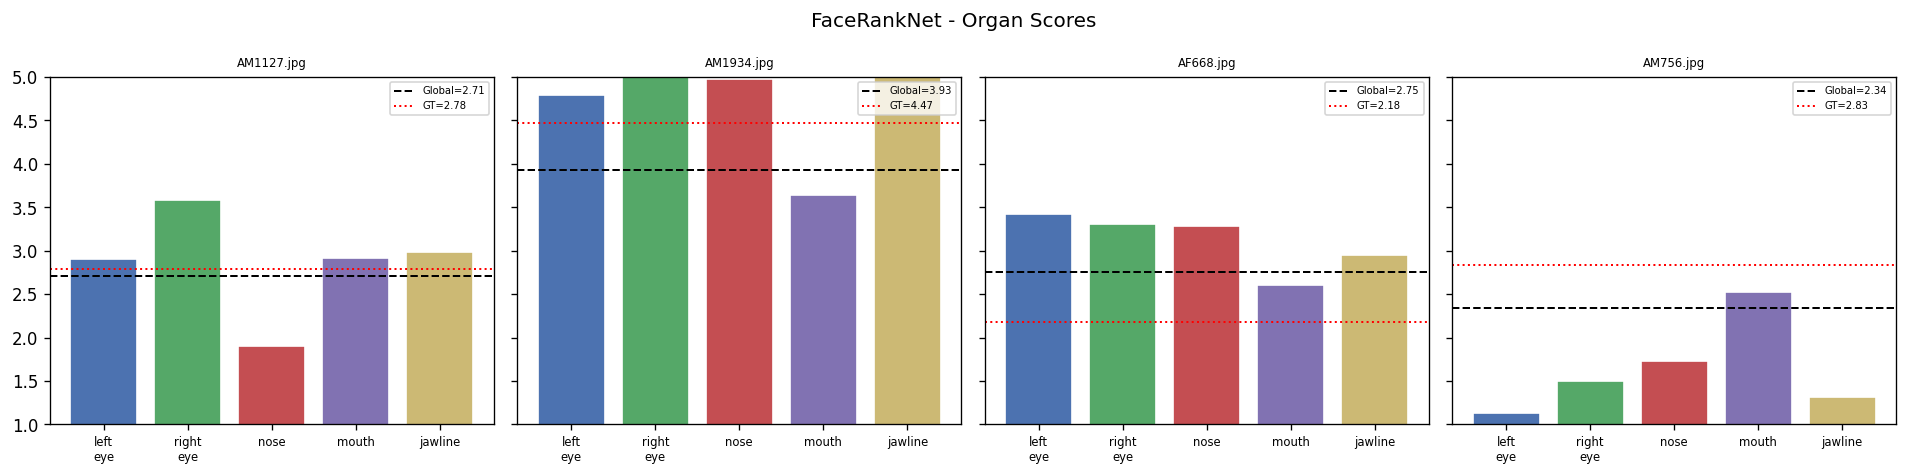

fusion_mode lacks cross-organ attention - skipping attention plots.
Figures saved to Drive.


In [11]:
# ============================================================
# Cell 10 - Visualisation: organ bar chart + cross-organ attention heatmap
# ============================================================
import torch, matplotlib.pyplot as plt, matplotlib, numpy as np
from dataset import collate_faces
from torch.utils.data import DataLoader

matplotlib.rcParams['figure.dpi'] = 120
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

sample_batch = next(iter(DataLoader(
    test_face_ds, batch_size=4, shuffle=False, collate_fn=collate_faces)))

trained_model.eval()
with torch.no_grad():
    sg  = {k: v.to(device) for k, v in sample_batch['subgraphs'].items()}
    out = trained_model(sg)

organ_names = list(out['local_scores'].keys())
n = len(sample_batch['filenames'])

# Fig 1: Organ score bar chart
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)
if n == 1: axes = [axes]
for i, ax in enumerate(axes):
    scores = [out['local_scores'][o][i].item() for o in organ_names]
    ax.bar(organ_names, scores, color=colors, edgecolor='white')
    ax.axhline(out['global_score'][i].item(), color='black', ls='--', lw=1.2,
               label=f'Global={out["global_score"][i].item():.2f}')
    ax.axhline(sample_batch['ratings'][i].item(), color='red', ls=':', lw=1.2,
               label=f'GT={sample_batch["ratings"][i].item():.2f}')
    ax.set_ylim(1, 5); ax.set_title(sample_batch['filenames'][i], fontsize=7)
    ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
    ax.legend(fontsize=6)
fig.suptitle('FaceRankNet - Organ Scores', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/organ_scores_bar.png', bbox_inches='tight')
plt.show()

# Fig 2 / 3: Cross-organ attention (skip when fusion_mode='fusion_weight')
if out['attn_weights'] is None:
    print("fusion_mode lacks cross-organ attention - skipping attention plots.")
else:
    attn = out['attn_weights'].cpu().numpy()
    attn_mean = attn.mean(axis=0)

    short_names = [o.replace('_eye','_e').replace('jawline','jaw') for o in organ_names]
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    im = ax2.imshow(attn_mean, cmap='YlOrRd', vmin=0, vmax=attn_mean.max())
    ax2.set_xticks(range(len(organ_names))); ax2.set_xticklabels(short_names, fontsize=9)
    ax2.set_yticks(range(len(organ_names))); ax2.set_yticklabels(short_names, fontsize=9)
    ax2.set_xlabel('Key (organ yang diperhatikan)'); ax2.set_ylabel('Query (organ yang memperhatikan)')
    for i in range(len(organ_names)):
        for j in range(len(organ_names)):
            ax2.text(j, i, f'{attn_mean[i,j]:.2f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax2)
    ax2.set_title('Cross-Organ Attention (rata-rata batch)', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_ROOT}/cross_organ_attention.png', bbox_inches='tight', dpi=150)
    plt.show()

    received = attn_mean.sum(axis=0)
    fig3, ax3 = plt.subplots(figsize=(6, 3))
    ax3.bar(short_names, received / received.sum(), color=colors, edgecolor='white')
    ax3.set_ylabel('Attention share'); ax3.set_title('Effective Organ Importance (dari attention)', fontsize=10)
    ax3.set_ylim(0, 0.5)
    for i, v in enumerate(received / received.sum()):
        ax3.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_ROOT}/organ_importance_attention.png', bbox_inches='tight', dpi=150)
    plt.show()
print('Figures saved to Drive.')

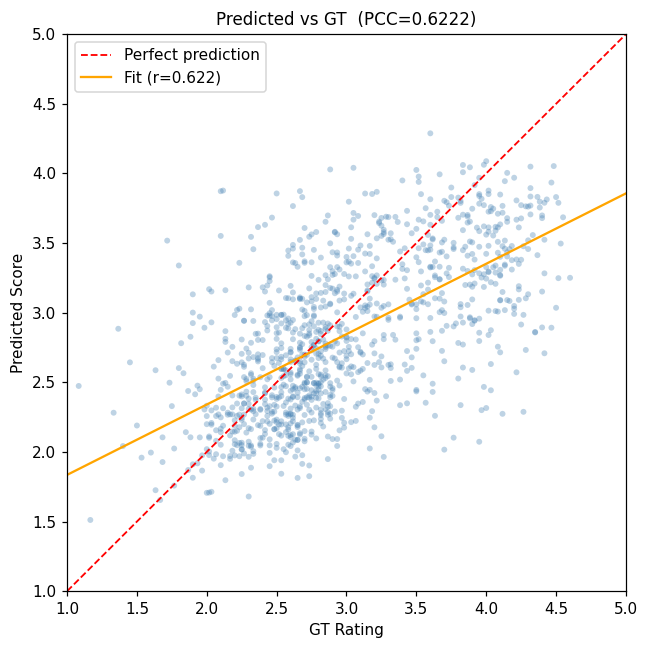

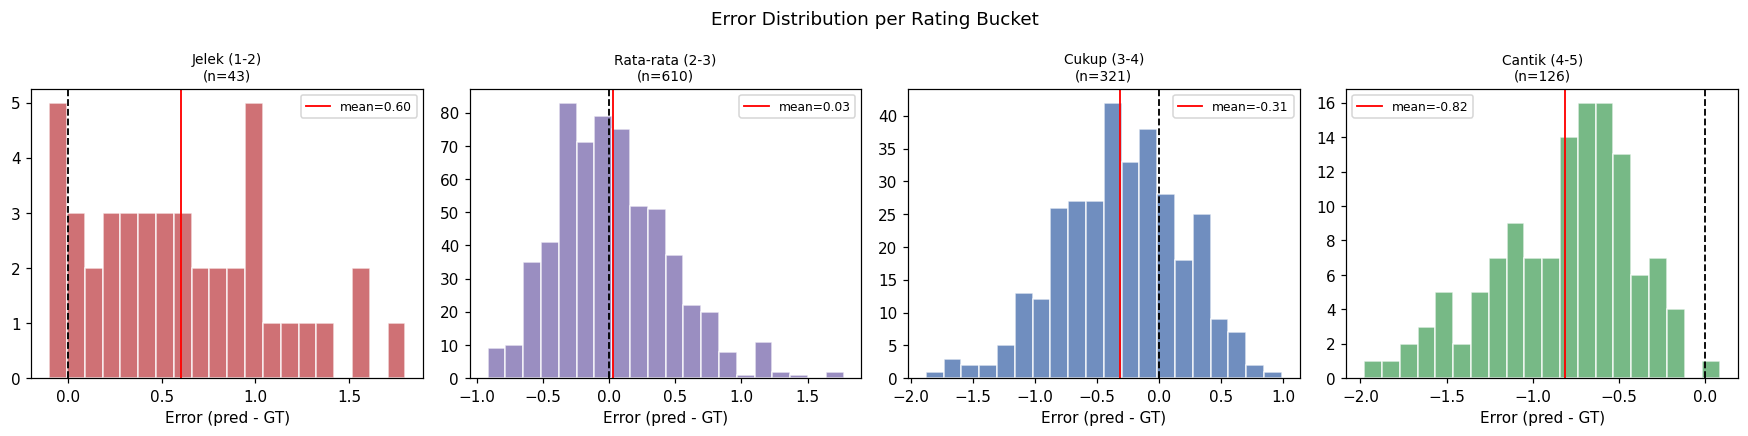

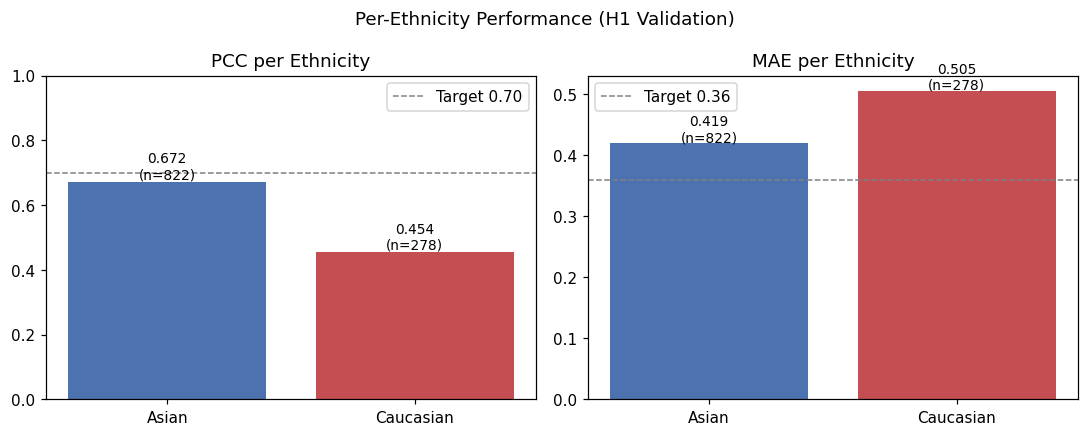

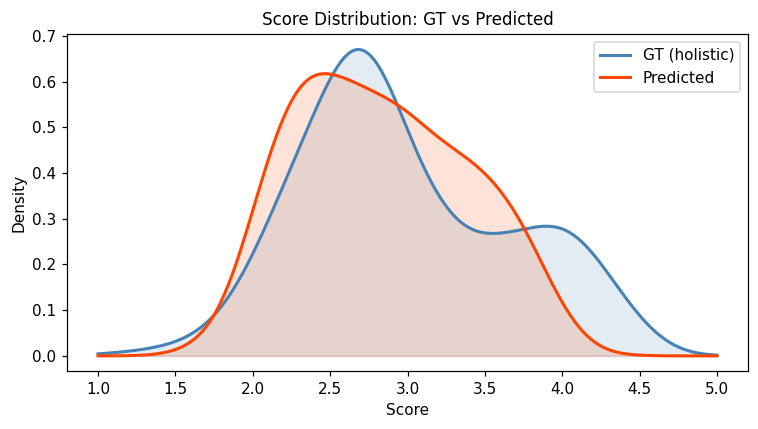


Top-K Ranking Precision:
     K |  Precision |   Recall
------------------------------
    10 |      10.0% |    10.0%
    25 |       8.0% |     8.0%
    50 |      18.0% |    18.0%
   100 |      31.0% |    31.0%

fusion_mode lacks cross-organ attention - skipping Fig 6.

Semua figure tersimpan ke Drive.


In [12]:
# ============================================================
# Cell 11 - Extended Evaluation
# 1. Scatter predicted vs GT
# 2. Error distribution per rating bucket
# 3. PCC/MAE per ethnicity (H1 check)
# 4. Score distribution KDE
# 5. Top-K ranking precision
# 6. Full test-set attention heatmap (skipped in fusion_weight mode)
# ============================================================
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib
from scipy import stats
from torch.utils.data import DataLoader
from dataset import collate_faces

matplotlib.rcParams['figure.dpi'] = 110

trained_model.eval()
all_preds, all_gts, all_files = [], [], []
all_attn = []

with torch.no_grad():
    for batch in DataLoader(test_face_ds, batch_size=64, shuffle=False, collate_fn=collate_faces):
        sg  = {k: v.to(device) for k, v in batch['subgraphs'].items()}
        out = trained_model(sg)
        all_preds.extend(out['global_score'].cpu().numpy())
        all_gts.extend(batch['ratings'].numpy())
        all_files.extend(batch['filenames'])
        if out['attn_weights'] is not None:
            all_attn.append(out['attn_weights'].cpu().numpy())

preds = np.array(all_preds)
gts   = np.array(all_gts)
files = np.array(all_files)
errors = preds - gts

# 1. Scatter plot: Predicted vs GT
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(gts, preds, alpha=0.35, s=15, color='steelblue', edgecolors='none')
lims = [1, 5]
ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect prediction')
m, b, r, p, _ = stats.linregress(gts, preds)
xs = np.linspace(1, 5, 100)
ax.plot(xs, m*xs + b, 'orange', lw=1.5, label=f'Fit (r={r:.3f})')
ax.set_xlabel('GT Rating'); ax.set_ylabel('Predicted Score')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title(f'Predicted vs GT  (PCC={np.corrcoef(gts, preds)[0,1]:.4f})', fontsize=11)
ax.legend(); plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/scatter_pred_vs_gt.png', bbox_inches='tight', dpi=150)
plt.show()

# 2. Error distribution per rating bucket
buckets = {'Jelek (1-2)': (1, 2), 'Rata-rata (2-3)': (2, 3),
           'Cukup (3-4)': (3, 4), 'Cantik (4-5)': (4, 5)}
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors4 = ['#C44E52','#8172B2','#4C72B0','#55A868']
for ax, (label, (lo, hi)), c in zip(axes, buckets.items(), colors4):
    mask = (gts >= lo) & (gts < hi)
    err  = errors[mask]
    ax.hist(err, bins=20, color=c, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.axvline(err.mean(), color='red', lw=1.2, ls='-', label=f'mean={err.mean():.2f}')
    ax.set_title(f'{label}\n(n={mask.sum()})', fontsize=9)
    ax.set_xlabel('Error (pred - GT)'); ax.legend(fontsize=8)
fig.suptitle('Error Distribution per Rating Bucket', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/error_per_bucket.png', bbox_inches='tight', dpi=150)
plt.show()

# 3. PCC & MAE per ethnicity (H1 evaluation)
test_df_loaded = pd.read_csv(TEST_CSV)
eth_map = dict(zip(test_df_loaded['Filename'], test_df_loaded['Ethnicity']))
ethnicities = {'Asian': [], 'Caucasian': []}
for f, p, g in zip(files, preds, gts):
    eth = eth_map.get(f, 'Unknown')
    if eth in ethnicities:
        ethnicities[eth].append((p, g))

eth_metrics = {}
for eth, vals in ethnicities.items():
    if not vals: continue
    ps, gs = zip(*vals)
    ps, gs = np.array(ps), np.array(gs)
    eth_metrics[eth] = {
        'PCC': float(np.corrcoef(ps, gs)[0,1]),
        'MAE': float(np.abs(ps - gs).mean()),
        'n'  : len(ps)
    }

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eth_names = list(eth_metrics.keys())
pccs = [eth_metrics[e]['PCC'] for e in eth_names]
maes = [eth_metrics[e]['MAE'] for e in eth_names]
ns   = [eth_metrics[e]['n']   for e in eth_names]

axes[0].bar(eth_names, pccs, color=['#4C72B0','#C44E52'])
axes[0].set_ylim(0, 1); axes[0].set_title('PCC per Ethnicity')
axes[0].axhline(0.70, color='gray', ls='--', lw=1, label='Target 0.70')
for i, (v, n) in enumerate(zip(pccs, ns)):
    axes[0].text(i, v+0.01, f'{v:.3f}\n(n={n})', ha='center', fontsize=9)
axes[0].legend()

axes[1].bar(eth_names, maes, color=['#4C72B0','#C44E52'])
axes[1].set_title('MAE per Ethnicity')
axes[1].axhline(0.36, color='gray', ls='--', lw=1, label='Target 0.36')
for i, (v, n) in enumerate(zip(maes, ns)):
    axes[1].text(i, v+0.003, f'{v:.3f}\n(n={n})', ha='center', fontsize=9)
axes[1].legend()

fig.suptitle('Per-Ethnicity Performance (H1 Validation)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/ethnicity_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

# 4. Score distribution KDE
from scipy.stats import gaussian_kde
fig, ax = plt.subplots(figsize=(7, 4))
xs = np.linspace(1, 5, 300)
for arr, label, c in [(gts, 'GT (holistic)', 'steelblue'), (preds, 'Predicted', 'orangered')]:
    kde = gaussian_kde(arr, bw_method=0.3)
    ax.plot(xs, kde(xs), label=label, lw=2, color=c)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=c)
ax.set_xlabel('Score'); ax.set_ylabel('Density')
ax.set_title('Score Distribution: GT vs Predicted', fontsize=11)
ax.legend(); plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/score_distribution_kde.png', bbox_inches='tight', dpi=150)
plt.show()

# 5. Top-K ranking precision
print("\nTop-K Ranking Precision:")
print(f"{'K':>6} | {'Precision':>10} | {'Recall':>8}")
print("-" * 30)
gt_rank   = np.argsort(-gts)
pred_rank = np.argsort(-preds)
for k in [10, 25, 50, 100]:
    top_gt   = set(gt_rank[:k])
    top_pred = set(pred_rank[:k])
    prec = len(top_gt & top_pred) / k
    rec  = len(top_gt & top_pred) / k
    print(f"{k:>6} | {prec:>10.1%} | {rec:>8.1%}")

# 6. Full test-set attention heatmap (skipped in fusion_weight mode)
if not all_attn:
    print("\nfusion_mode lacks cross-organ attention - skipping Fig 6.")
else:
    organ_names = ['left_eye','right_eye','nose','mouth','jawline']
    short_names  = ['l_eye','r_eye','nose','mouth','jaw']
    attn_all = np.concatenate(all_attn, axis=0)
    attn_mean = attn_all.mean(axis=0)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(attn_mean, cmap='YlOrRd')
    ax.set_xticks(range(5)); ax.set_xticklabels(short_names, fontsize=9)
    ax.set_yticks(range(5)); ax.set_yticklabels(short_names, fontsize=9)
    ax.set_xlabel('Key (diperhatikan)'); ax.set_ylabel('Query (yang memperhatikan)')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{attn_mean[i,j]:.3f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Cross-Organ Attention  (N={len(attn_all)} test faces)', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_ROOT}/attention_fulltest.png', bbox_inches='tight', dpi=150)
    plt.show()
print('\nSemua figure tersimpan ke Drive.')